# Procesamiento de Aforos Vehiculares Empíricos

Extracción y procesamiento de tasas de flujo vehicular y distribución por tipo de vehículo desde registros de video en intersección crítica.

## Fuente de Datos

Datos extraídos de la Tabla 13, tesis Sarango (2025).

**Instrumento:** [Cámara Sony IMX766 y Dron DJI Phantom 4 Pro V2.0]

**Ubicación:** [Avenida Isidro Ayora y la Avenida 8 de Diciembre]

**Fecha/Hora videos:** [13 de enero de 2025]

![Tabla 14 - Registro de aforos vehiculares](./imagen_tabla_14.png)

In [5]:
import os
from dotenv import load_dotenv
load_dotenv()

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob

## Datos de Flujo Vehicular

Datos extraidos de la Tabla 13 de la tesis Sarango (2025).

Referencia:
- Tesis: "Analisis de trafico vehicular en interseccion critica"
- Autor: E. Sarango (2025)
- Ubicacion: Av. Isidro Ayora y Av. 8 de Diciembre, Loja
- Instrumento: Camara Sony IMX766 y Dron DJI Phantom 4 Pro
- Fecha: 13 de enero de 2025

Variables:
- Muestra_Video: identificador del video de analisis
- Vehiculos_Detectados: conteo total de vehiculos en el video
- Tiempo_segundos: duracion del video en segundos
- Flujo_veh_seg: tasa de flujo en vehiculos/segundo
- Flujo_veh_min: tasa de flujo en vehiculos/minuto
- Tasa_Flujo_veh_h: tasa de flujo en vehiculos/hora (calculada)

In [6]:
data = {
    'Muestra_Video': ['ANALISIS_1', 'ANALISIS_2', 'ANALISIS_3', 'ANALISIS_4', 'ANALISIS_5', 'ANALISIS_6', 'ANALISIS_7'],
    'Vehiculos_Detectados': [135, 60, 33, 116, 120, 132, 38],
    'Tiempo_segundos': [410, 192, 92, 330, 344, 410, 119],
    'Flujo_veh_seg': [0.329, 0.307, 0.337, 0.348, 0.349, 0.280, 0.319],
    'Flujo_veh_min': [19.76, 18.44, 20.26, 20.91, 20.94, 16.84, 19.19],
}

df = pd.DataFrame(data)
df['Tasa_Flujo_veh_h'] = df['Flujo_veh_seg'] * 3600

## Distribución Vehicular por Tipo

Conteo de vehículos clasificados por tipo a partir de las etiquetas del dataset.

In [7]:
# API key debe estar en variable de entorno ROBOFLOW_API_KEY
from roboflow import Roboflow
rf = Roboflow(api_key=os.getenv("ROBOFLOW_API_KEY"))
project = rf.workspace("bd20244-cy0u2").project("bd_2024_4-vxbuf")
version = project.version(1)
dataset = version.download("yolov11")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to BD_2024_4-1 in yolov11:: 100%|██████████| 6592/6592 [00:00<00:00, 8191.58it/s] 


## Conteo de Vehiculos por Tipo (YOLO)

Conteo de vehiculos clasificados usando YOLOv5.

Referencia:
- Dataset: BD_2024_4 (conteo vehicular Loja)
- Modelo: YOLOv11 fine-tuned
- Clases: 0=Pesados, 1=Ligeros, 2=Motos

In [8]:
ruta_labels = 'BD_2024_4-1/train/labels/*.txt'

# Mapeo de IDs YOLO: 1=Ligeros, 2=Motos, 0=Pesados
conteo_clases = {
    '1': 0,
    '2': 0,
    '0': 0
}

In [9]:
archivos = glob.glob(ruta_labels)
for archivo in archivos:
    with open(archivo, 'r') as f:
        for linea in f:
            partes = linea.strip().split()
            if partes and partes[0] in conteo_clases:
                conteo_clases[partes[0]] += 1

total_vehiculos = sum(conteo_clases.values())

df_distribucion = pd.DataFrame({
    'Tipo_Vehiculo': ['Ligeros', 'Motos', 'Pesados'],
    'Conteo': [conteo_clases['1'], conteo_clases['2'], conteo_clases['0']]
})
df_distribucion['Porcentaje'] = (df_distribucion['Conteo'] / total_vehiculos) * 100

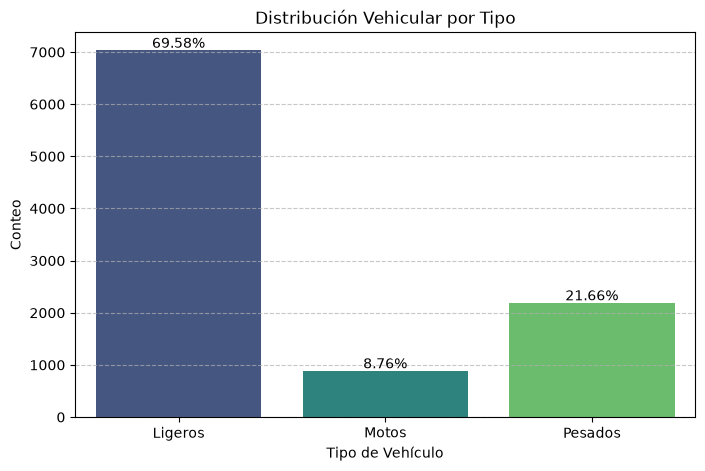

In [10]:
plt.figure(figsize=(8, 5))
sns.barplot(x='Tipo_Vehiculo', y='Conteo', data=df_distribucion, hue='Tipo_Vehiculo', palette='viridis', legend=False)
plt.title('Distribución Vehicular por Tipo')
plt.xlabel('Tipo de Vehículo')
plt.ylabel('Conteo')
for i, row in df_distribucion.iterrows():
    plt.text(i, row['Conteo'] + 50, f"{row['Porcentaje']:.2f}%", ha='center')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [11]:
display(df_distribucion.style.format({'Porcentaje': '{:.2f}%'}))

,Tipo_Vehiculo,Conteo,Porcentaje
0,Ligeros,7032,69.58%
1,Motos,885,8.76%
2,Pesados,2189,21.66%


## Estadisticas Descriptivas

Resumen estadistico de las tasas de flujo vehicular calculadas.

Metricas:
- Media, desviacion estandar, minimo, maximo
- Unidades: veh/s, veh/min, veh/h

## Estadísticas Descriptivas del Flujo

In [12]:
resumen = pd.DataFrame({
    'Métrica': ['Flujo promedio', 'Desviación estándar', 'Mínimo', 'Máximo'],
    'veh/s': [df['Flujo_veh_seg'].mean(), df['Flujo_veh_seg'].std(), df['Flujo_veh_seg'].min(), df['Flujo_veh_seg'].max()],
    'veh/min': [df['Flujo_veh_min'].mean(), df['Flujo_veh_min'].std(), df['Flujo_veh_min'].min(), df['Flujo_veh_min'].max()],
    'veh/h': [df['Tasa_Flujo_veh_h'].mean(), df['Tasa_Flujo_veh_h'].std(), df['Tasa_Flujo_veh_h'].min(), df['Tasa_Flujo_veh_h'].max()]
})

resumen.style.format({'veh/s': '{:.3f}', 'veh/min': '{:.2f}', 'veh/h': '{:.1f}'})

,Métrica,veh/s,veh/min,veh/h
0,Flujo promedio,0.324,19.48,1166.9
1,Desviación estándar,0.025,1.47,88.7
2,Mínimo,0.280,16.84,1008.0
3,Máximo,0.349,20.94,1256.4


## Visualización del Flujo Vehicular

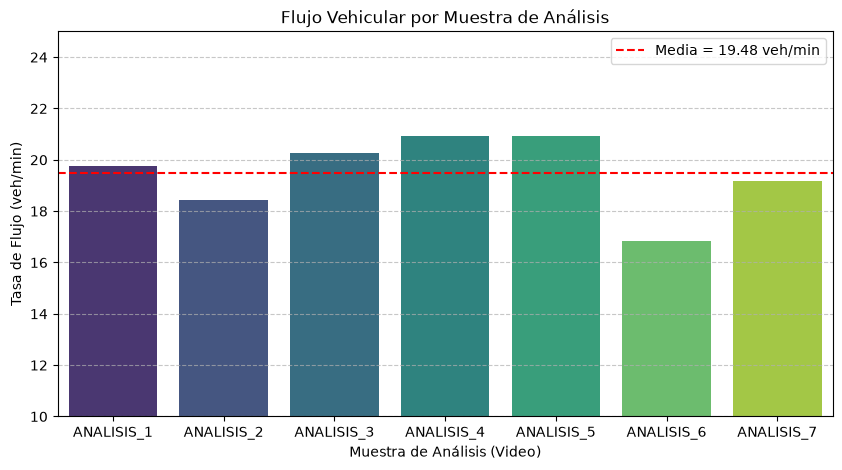

In [13]:
plt.figure(figsize=(10, 5))
sns.barplot(x='Muestra_Video', y='Flujo_veh_min', data=df, hue='Muestra_Video', palette='viridis', legend=False)
plt.axhline(df['Flujo_veh_min'].mean(), color='red', linestyle='--', label=f'Media = {df["Flujo_veh_min"].mean():.2f} veh/min')
plt.title('Flujo Vehicular por Muestra de Análisis')
plt.xlabel('Muestra de Análisis (Video)')
plt.ylabel('Tasa de Flujo (veh/min)')
plt.ylim(10, 25)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [14]:
df.style.format({
    'Flujo_veh_seg': '{:.3f}',
    'Flujo_veh_min': '{:.2f}',
    'Tasa_Flujo_veh_h': '{:.1f}'
})
display(df)

,Muestra_Video,Vehiculos_Detectados,Tiempo_segundos,Flujo_veh_seg,Flujo_veh_min,Tasa_Flujo_veh_h
0,ANALISIS_1,135,410,0.329,19.76,1184.4
1,ANALISIS_2,60,192,0.307,18.44,1105.2
2,ANALISIS_3,33,92,0.337,20.26,1213.2
3,ANALISIS_4,116,330,0.348,20.91,1252.8
4,ANALISIS_5,120,344,0.349,20.94,1256.4
5,ANALISIS_6,132,410,0.280,16.84,1008.0
6,ANALISIS_7,38,119,0.319,19.19,1148.4
